## Pricing a call option

task 1

In [1]:
from math import log, sqrt, exp
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

In [2]:
S = 52 # stock price at time t in dollars
K = 50 # strike price in dollars
r = 0.12 # risk free rate
sigma = 0.3 # volatility of the stock
time = 3/12 # time to maturity, as fraction of a year

In [3]:
def Black_Scholes(time, S, K, r, sigma):

    d1 = ( log( S/K ) + (r + sigma**2 /2) * ( time ) ) / (sigma * sqrt ( time ) )
    d2 = d1 - sigma * sqrt( time )
    
    C = norm.cdf( d1 ) * S - norm.cdf( d2 ) * K * exp( -r * time )

    return C


In [4]:
BC_option_price = Black_Scholes(time, S, K, r, sigma)
print(f"According to the Black-Scholes model the fair option price is ${BC_option_price:.2f}")

According to the Black-Scholes model the fair option price is $5.06


task 2

In [5]:
def construct_tree(S, K, time, r, sigma, n):

    dt = time/n  # time between each step
    u = exp( sigma * sqrt(dt) ) # formula for each up movement
    d = 1/u                     # down movement is inverse of up
    p = ( exp( r * dt ) - d ) / ( u - d ) # probality of up movement

    prices = []
    probablities = []

    for i in range(n + 1):
        prices.append( [S * ( u**j ) * ( d**(i-j) ) for j in range(i + 1) ] )   # add list of all possible prices at step i
        probablities.append( [ comb(i, j) * p**j * ( (1-p)**(i-j) ) for j in range(i + 1) ] ) # add list of all possible probabilites at step i
    
    return prices, probablities

plot tree

In [6]:
def plot_tree(prices, probabilites):
    plt.figure(figsize=(8, 6))

    for i in range(len(prices)):
        for j, (price, prob) in enumerate(zip(prices[i], probabilites[i])):
            plt.scatter(i, price, color='blue')         # node with price and probability
            plt.text(i, price, f"{price:.2f}\n({prob:.2f})", fontsize=10)
            
            if i > 0 and j < len(prices[i-1]):  # avoid errors
                plt.plot([i-1, i], [prices[i-1][j], price], 'k-')  # move up
            if i > 0 and j > 0:
                plt.plot([i-1, i], [prices[i-1][j-1], price], 'k-')  # move down
                
    plt.xlabel("Time Steps")
    plt.ylabel("Stock Price")
    plt.xticks(range(n + 1))  # make the x-axis only integers
    plt.grid()
    plt.show()

find price of option

In [7]:
def discrete_price(S, K, time, r, sigma, n):

    price_tree, probability_tree = construct_tree(S, K, time, r, sigma, n)

    expected_value = 0
    end_prices = price_tree[-1]   # prices after going n steps
    end_probabilities = probability_tree[-1]   # probabilities after going n steps

    for i in range( len(end_prices) ):
    
        if end_prices[i] > K:
            expected_value += ( end_prices[i] - K ) * end_probabilities[i]
    
    NPV = expected_value * exp( -r * time )

    return NPV

i) 1 step:

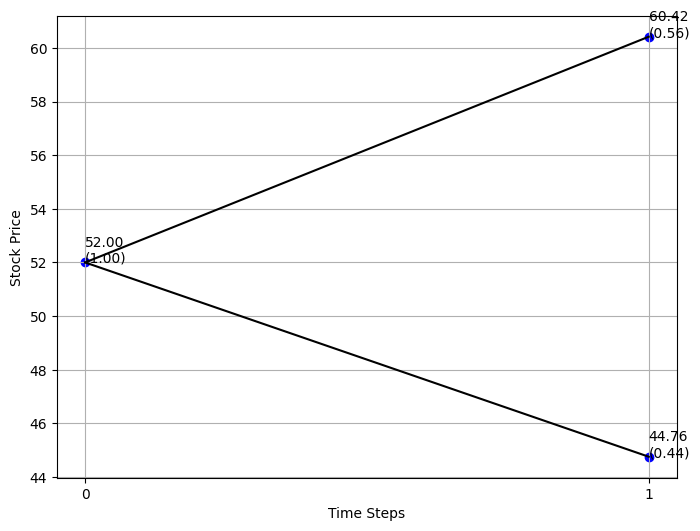

In [8]:
n = 1  # number of steps
prices, probabilites = construct_tree(S, K, time, r, sigma, n)
plot_tree(prices, probabilites)

In [9]:
print(f"According to the binomial-tree model with only 1 step the fair price is ${discrete_price(S, K, time, r, sigma, n):.2f}")

According to the binomial-tree model with only 1 step the fair price is $5.70


ii) 2 steps

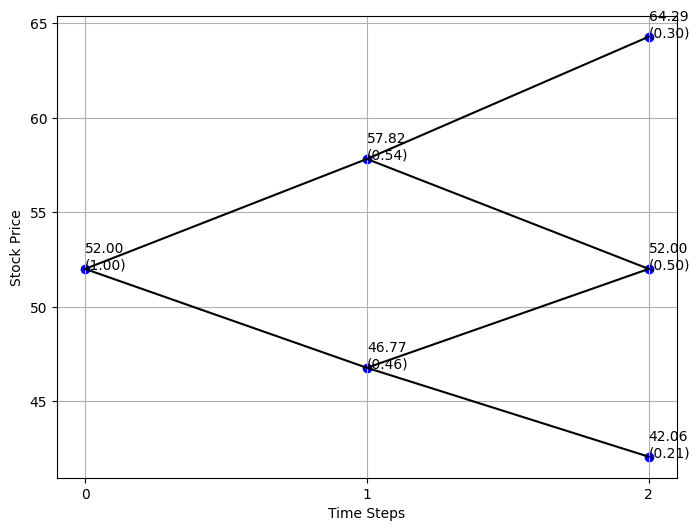

In [10]:
n = 2  # number of steps
prices, probabilites = construct_tree(S, K, time, r, sigma, n)
plot_tree(prices, probabilites)

In [11]:
print(f"According to the binomial-tree model with 2 steps the fair price is ${discrete_price(S, K, time, r, sigma, n):.2f}")

According to the binomial-tree model with 2 steps the fair price is $5.08


iii) 3 steps

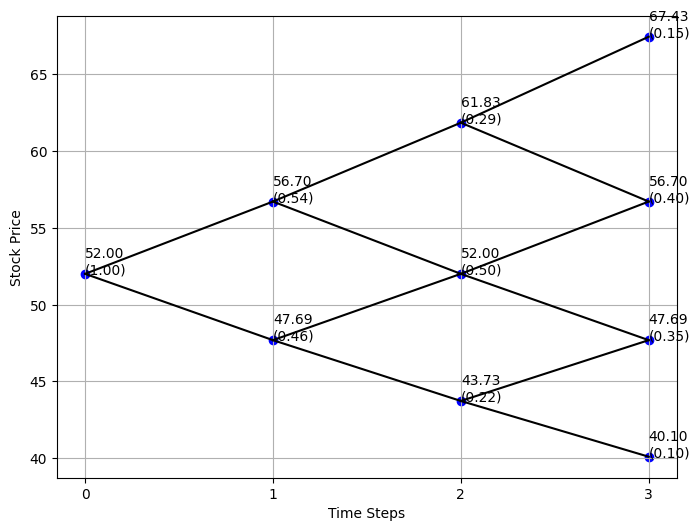

In [12]:
n = 3  # number of steps
prices, probabilites = construct_tree(S, K, time, r, sigma, n)
plot_tree(prices, probabilites)

In [13]:
print(f"According to the binomial-tree model with 3 steps the fair price is ${discrete_price(S, K, time, r, sigma, n):.2f}")

According to the binomial-tree model with 3 steps the fair price is $5.21


iv) n steps

In [15]:
print(f"steps:  |   option price:")
for i in range(1,11):
    print(f"{i:<2}      |   ${discrete_price(S, K, time, r, sigma, i) :.2f}")

steps:  |   option price:
1       |   $5.70
2       |   $5.08
3       |   $5.21
4       |   $5.13
5       |   $5.11
6       |   $5.13
7       |   $5.07
8       |   $5.12
9       |   $5.04
10      |   $5.12


According to Black-Scholes the price should be $5.06, it looks like the binomial tree is getting closer to that the more steps we include. But the convergence is not monotonic as the price is going up and down as we increase the number of steps

task 3

In [ ]:
def MC(time, S, K, r, sigma, dt, num_traject):

    num_steps = int( time/dt )  # amount of steps

    global St_list
    St_list = [S]*num_traject # list with each trajectory

    for i in range(num_traject):

        for j in range(num_steps):
            St_list[i] += St_list[i] * ( r * dt + sigma * sqrt( dt ) * np.random.randn() )  
    
    expected_value = 0
    for price in St_list:
        if price > K:
            expected_value += price - K
    expected_value = expected_value * exp(-r * time ) / num_traject   # discount to present value and find the average
    

    return expected_value

In [ ]:
dt = 1/365 # time step of 1 day
num_traject = 1000
MC_option_price = MC(time,S,K,r,sigma,dt,num_traject)

In [ ]:
print(f"according to the Monte Carlo simulation the price of the option should be ${MC_option_price:.2f}")
print(f"according to the Black-Scholes model the price of the option should be ${BC_option_price:.2f}")
print(f"that means the Monte Carlo error is ${MC_option_price - BC_option_price :.2f}")

according to the Monte Carlo simulation the price of the option should be $5.23
according to the Black-Scholes model the price of the option should be $5.06
that means the Monte Carlo error is $0.18


Plot showing the range and frequency of the stock value computed by the Monte Carlo simulation

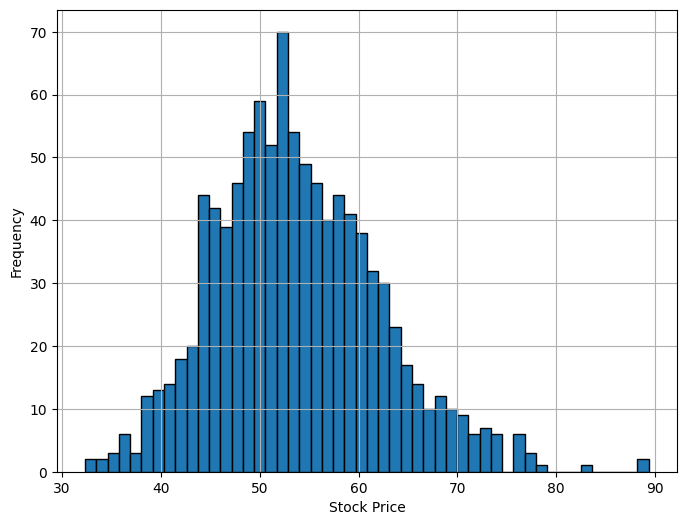

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(St_list, bins=50, edgecolor='black')

plt.xlabel("Stock Price")
plt.ylabel("Frequency")



plt.grid()
plt.show()